In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
connect = sqlite3.connect('../data/checking-logs.sqlite')

In [3]:
query = """
    SELECT uid,
        timestamp
    FROM checker
    WHERE uid LIKE "user_%"
"""
df = pd.read_sql(query, connect, parse_dates=['timestamp'])

In [4]:
week_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_users = df.copy()
for day in week_days:
    df_users[day] = (df_users['timestamp'].dt.day_name() == day)

df_users = df_users.drop('timestamp', axis=1)
df_users = df_users.groupby('uid').sum()
df_users_sorted = df_users.loc[df_users.sum(axis=1).sort_values(ascending=False).index]
df_users_sorted = df_users_sorted.transpose()
df_users_sorted.shape

(7, 30)

In [8]:
df_users_sorted.head()

uid,user_4,user_14,user_2,user_25,user_19,user_26,user_20,user_31,user_10,user_3,...,user_17,user_16,user_27,user_15,user_6,user_11,user_7,user_22,user_23,user_0
Monday,35,50,24,14,7,0,23,5,0,46,...,8,10,0,0,1,0,0,2,0,3
Tuesday,86,87,131,44,9,1,0,0,16,11,...,4,5,0,0,0,0,5,3,0,0
Wednesday,33,0,32,15,0,34,8,0,37,0,...,1,0,0,0,4,0,3,0,0,0
Thursday,108,17,4,40,78,51,96,7,77,7,...,17,14,15,5,2,0,0,2,6,0
Friday,61,0,0,10,10,2,7,35,1,59,...,0,0,0,0,0,0,0,0,0,0


In [11]:
day_hours = list(range(24))
df_users_hour = df.copy()
for hour in day_hours:
    df_users_hour[hour] = (df_users_hour['timestamp'].dt.hour == hour)

df_users_hour = df_users_hour.drop('timestamp', axis=1)
df_users_hour = df_users_hour.groupby('uid').sum()
df_users_hour_sorted = df_users_hour.loc[df_users_hour.sum(axis=1).sort_values(ascending=False).index]
df_users_hour_sorted = df_users_hour_sorted.transpose()
df_users_hour_sorted.shape

(24, 30)

In [13]:
df_users_hour_sorted.head()

uid,user_4,user_14,user_2,user_25,user_19,user_26,user_20,user_31,user_10,user_3,...,user_17,user_16,user_27,user_15,user_6,user_11,user_7,user_22,user_23,user_0
0,0,4,0,0,0,4,0,2,0,0,...,0,0,0,0,2,0,0,0,0,0
1,0,6,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


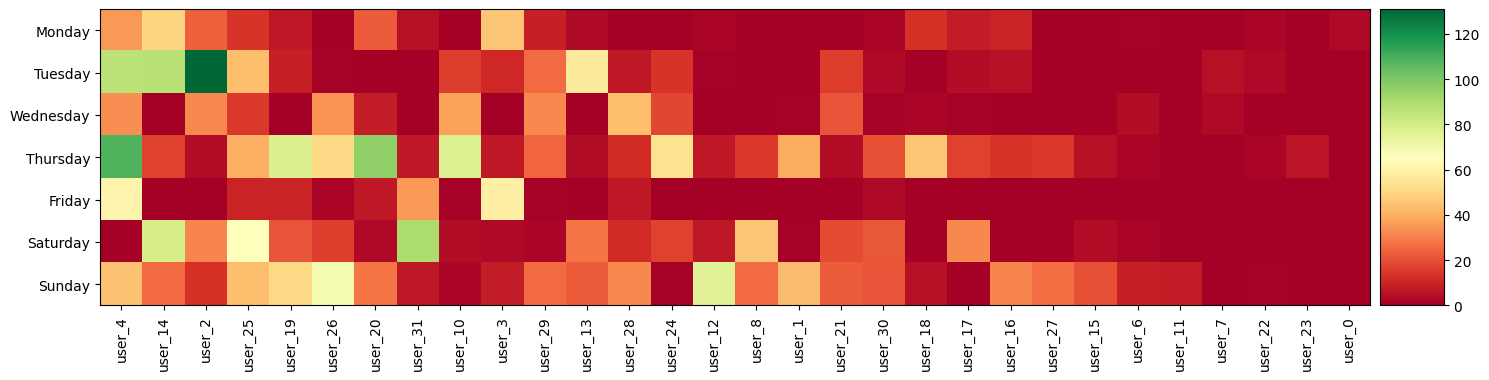

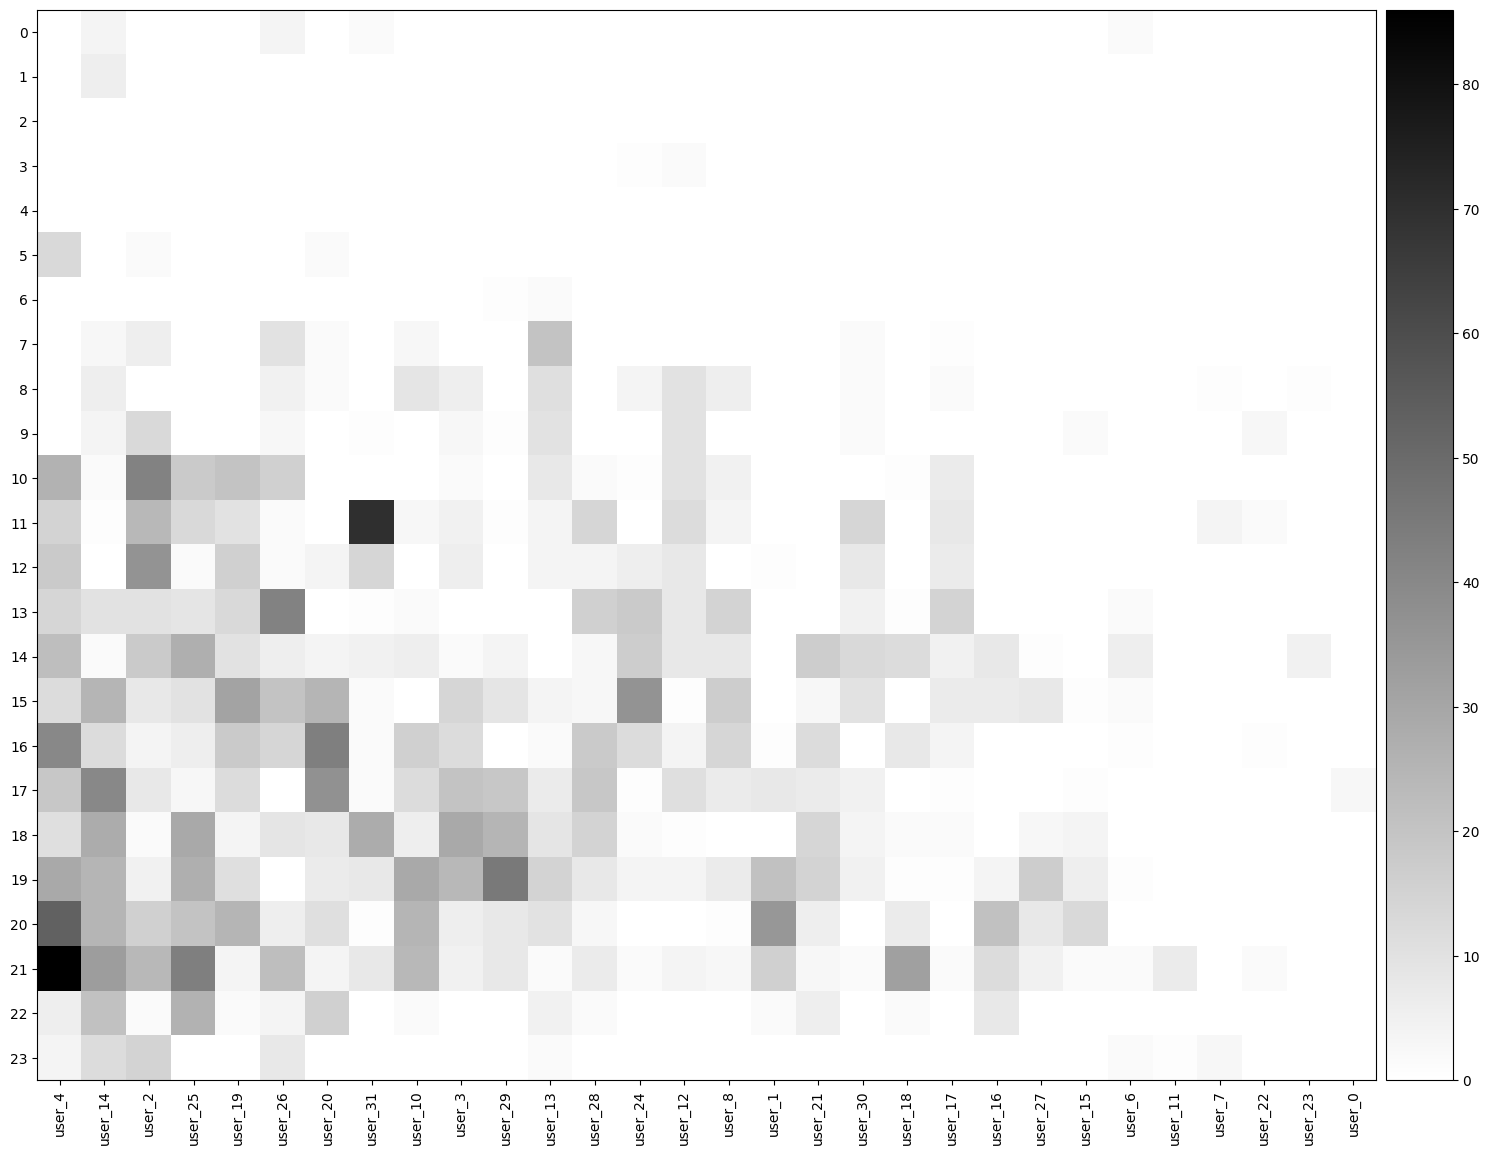

In [14]:
plt.figure(figsize=(15, 12))
ax = plt.gca()
im = ax.imshow(df_users_sorted, cmap='RdYlGn')
ax.set_xticks(range(len(df_users_sorted.columns)))
ax.set_xticklabels(df_users_sorted.columns, rotation=90)
ax.set_yticks(range(len(df_users_sorted.index)))
ax.set_yticklabels(df_users_sorted.index)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im, cax=cax)

plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 12))
ax = plt.gca()
im = ax.imshow(df_users_hour_sorted, cmap='binary')
ax.set_xticks(range(len(df_users_hour_sorted.columns)))
ax.set_xticklabels(df_users_hour_sorted.columns, rotation=90)
ax.set_yticks(range(len(df_users_hour_sorted.index)))
ax.set_yticklabels(df_users_hour_sorted.index)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im, cax=cax)

plt.tight_layout()
plt.show()

In [82]:
connect.close()

### Какой пользователь имеет больше всего коммитов во вторник?
### Ответ: user_2
### Какой пользователь имеет больше всего коммитов в Чт?
### Ответ: user_4
### В какой день недели пользователи не любят делать много коммитов?
### Ответ: Fri
### Какой пользователь в какой час сделал наибольшее количество коммитов?
### Ответ: user_4, 21